In [1]:
#importing libraries
import numpy as np
import random
import matplotlib
import matplotlib.pyplot as plt
import copy

In [2]:
#configuring the graph display
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython: 
    from IPython import display

In [3]:
def pt_giver_4(x, y, pos):
    if pos == 1:
        return [x   ,y+1]
    elif pos == 2:
        return [x+1 ,y  ]
    elif pos == 3:
        return [x   ,y-1]
    elif pos == 4:
        return [x-1 ,y  ]

In [4]:
def pt_giver_8(x, y, pos):
    if pos == 1:
        return [x   ,y+1]
    elif pos == 2:
        return [x+1 ,y+1]
    elif pos == 3:
        return [x+1 ,y  ]
    elif pos == 4:
        return [x+1 ,y-1]
    elif pos == 5:
        return [x   ,y-1]
    elif pos == 6:
        return [x-1 ,y-1]
    elif pos == 7:
        return [x-1 ,y  ]
    elif pos == 8:
        return [x-1 ,y+1]

In [5]:
def periodic_conditioned_pt(pt, periodic_cond):
    if pt[0] > periodic_cond:
        pt[0] = -periodic_cond + (pt[0] -periodic_cond)
    if pt[0] < -periodic_cond:
        pt[0] = periodic_cond + (pt[0] + periodic_cond)
    if pt[1] > periodic_cond:
        pt[1] = -periodic_cond + (pt[1] -periodic_cond)  # -3  + (4 -3) = -2
    if pt[1] < -periodic_cond:
        pt[1] = periodic_cond + (pt[1] + periodic_cond)     
    return pt

In [6]:
def equivalent_point(x, y, periodic_cond):
    if periodic_cond > -1:
        if abs(x) == periodic_cond:
            if abs(y) == periodic_cond:
                return [x, -x], [y, -y]
            else:
                return [x, -x], [y, y]

        elif abs(y) == periodic_cond:
            return [x, x], [y, -y]
    
    return [x], [y]

In [7]:
def next_point(x, y, no_of_neighbours, equal_prob, prob_wt, periodic_cond):
    if no_of_neighbours == 4:
        if equal_prob:
            prob_wt = [0.25, 0.25, 0.25, 0.25]
        
        assert (len(prob_wt) == 4), "number of neighbours = %d, but prob_wt has only %d values" %(no_of_neighbours, len(prob_wt))
        population = list(range(1,4+1))
        pos = random.choices(population, prob_wt) [0] # [0] used as result is a list
        if periodic_cond > -1:
            return periodic_conditioned_pt( pt_giver_4(x, y, pos), periodic_cond)
        else:
            return pt_giver_4(x, y, pos)
    
    elif no_of_neighbours == 8:
        if equal_prob:
            prob_wt = [0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125]

        assert (len(prob_wt) == 8), "#neighbours = %d, but prob_wt has only %d values" %(no_of_neighbours, len(prob_wt))
        population = list(range(1,8+1))
        pos = random.choices(population, prob_wt) [0]
        if periodic_cond > 0:
            return periodic_conditioned_pt( pt_giver_8(x, y, pos), periodic_cond)
        else:
            return pt_giver_8(x, y, pos)

In [8]:
def draw_arrow(A, B, i, arrow_num_anno):
    dx = B[0] - A[0]
    dy = B[1] - A[1]
    
    plt.arrow(A[0], A[1], dx, dy, head_length=0.3, head_width= 0.3,  length_includes_head=True)
    if arrow_num_anno:
        plt.annotate('%d'%i, xy=(A[0]+dx/2, A[1]+dy/2), xytext=(0.2, 0.2), textcoords='offset points')

In [9]:
def map_scaler(x_pts, y_pts, centered_origin, periodic_cond):
    a, b = min(x_pts), max(x_pts)
    c, d = min(y_pts), max(y_pts)
        
    if periodic_cond != -1:
        
        plt.xticks(range(-periodic_cond, periodic_cond+1))
        plt.yticks(range(-periodic_cond, periodic_cond+1))
        plt.xlim(-periodic_cond, periodic_cond)
        plt.ylim(-periodic_cond, periodic_cond)
        
    elif centered_origin:
        equal_scaler = max( abs(a), abs(b), abs(c), abs(d))
                         
        plt.xticks(range(-1*equal_scaler -1, equal_scaler+2))
        plt.yticks(range(-1*equal_scaler -1, equal_scaler+2))
    else:
        plt.xticks(range(a-1, b+2))
        plt.yticks(range(c-1, d+2))

In [10]:
def plot(x_pts, y_pts, points, arrow_num_anno, centered_origin, show_path, periodic_cond):
    
    plt.clf()  
    plt.grid(True)
    
    if show_path:
        plt.plot(x_pts, y_pts, 'ro') 
        for j in range(0,len(x_pts)-1):
            draw_arrow(points[j], points[j+1], j+1, arrow_num_anno)
        
    else:
        #ptx, pty = x_pts[-1], y_pts[-1]
        ptx, pty = equivalent_point(x_pts[-1], y_pts[-1], periodic_cond)
        plt.plot(ptx, pty, 'ro')
    
    map_scaler(x_pts, y_pts, centered_origin, periodic_cond)
    if is_ipython: 
        display.clear_output(wait=True)   # Make it false for quick execution
    plt.show()

In [11]:
def random_walk(iterations, no_of_neighbours= 4, equal_prob= True, prob_wt= [], show_path = True, arrow_num_anno= True, 
                centered_origin= True, periodic_cond = -1, new= True, old_path = None):
    
    if new:
        points = [ [0,0] ]                #[ [x1, y1], [x2, y2] ... [xn, yn] ], we are starting at (0,0)
    else:
        points = copy.deepcopy(old_path)  # given path should be deep-copied as functions pass arrays by-references 
    for i in range(len(points)-1,len(points)-1+iterations):    # len(points) used for counting the old_path iterations, if new is false

        nxt_pt = next_point(points[i][0], points[i][1], no_of_neighbours, equal_prob, prob_wt, periodic_cond)
        points.append(nxt_pt)
            
        x_pts, y_pts = zip(*points)
        plot(x_pts, y_pts, points, arrow_num_anno, centered_origin, show_path, periodic_cond)  

    return points

In [12]:
##########################################################################################################################################

In [20]:
# Main Program
iterations = 10
#prob_wt = [.93, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01] # Up-direction biased
#prob_wt = [0.05, 0.20, 0.05, 0.20, 0.05, 0.20, 0.05, 0.20] # diagonals are favoured
prob_wt = [.65, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05]
no_of_neighbours= 8
equal_prob= True
show_path = False
arrow_num_anno = False
centered_origin= True
periodic_cond = 3

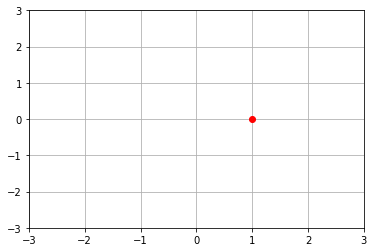

[[0, 0],
 [1, 1],
 [0, 1],
 [1, 2],
 [0, 1],
 [-1, 0],
 [-1, 1],
 [-2, 2],
 [-3, 1],
 [2, 0],
 [1, 0]]

In [21]:
#random_walk(iterations)
#random_walk(iterations, no_of_neighbours= 4, equal_prob= True, arrow_num_anno= False, centered_origin= True)
random_walk(iterations, no_of_neighbours, equal_prob, prob_wt, show_path, 
            arrow_num_anno, centered_origin, periodic_cond)

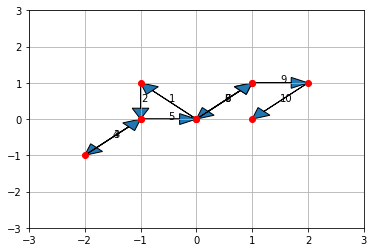

In [19]:
path = random_walk(iterations, no_of_neighbours= 8, equal_prob= True, prob_wt= prob_wt, arrow_num_anno= True,
                   centered_origin= True, new = True)

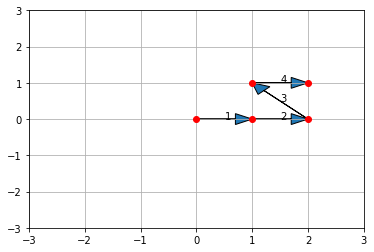

In [213]:
extended_path = random_walk(iterations, no_of_neighbours= 8, equal_prob= True, prob_wt= prob_wt, arrow_num_anno= True, 
            centered_origin= True, new = False, old_path = path)

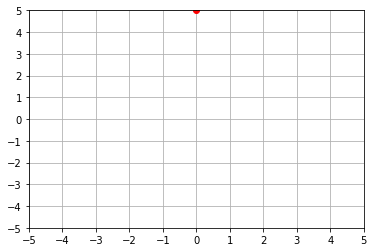

[[0, 0], [0, 1], [0, 2], [0, 3], [0, 4], [0, 5]]

In [81]:
#random_walk(iterations)
#random_walk(iterations, no_of_neighbours= 4, equal_prob= True, arrow_num_anno= False, centered_origin= True)
random_walk(iterations, no_of_neighbours, equal_prob, prob_wt, show_path, 
            arrow_num_anno, centered_origin, periodic_cond)